Regression and Classification

## OUTLINE: 

Data pre-processing, regression task and classification task

1. Reading the files
2. Missing Values
3. Imputing categorical variables
4. Imputing numerical variables
5. Classification with Decision Tree, single split
6. Classification with Decision Tree, Cross validation
7. Interpretation of the results

## Important instructions:

Each function you make will be considered during the grading, so it is important to strictly follow input and output instructions stated in the skeleton code.

You must not delete any of the given cells or change the structure of the cells or change the instructions in the cells or add cells (unless completely necessary, add a comment on why you added a cell) as they will help in grading the assignment. Should you contravene this provision, you will fail the assignment, and no feedback will be given on the part after the contravention.

Some variable names are already given and have random values or empty arrays assigned on them. In this case you should only change the assignments on the variables but keep the names as given.

When you are finished with implementing all the tasks, **clear all outputs, run all cells again** (make sure there is no error) and submit!

Make sure that the results and figures asked are visible for us to grade.

Make sure not to modify the files in the "data" folder in your submission, and not to change the folder structure or the files location, or your submission will not obtain a passing grade.

To ensure consistent results, make sure that every operation in which you can use a random seed has it set to 8. If your process is correct, but the results are wrong due to the seed being wrong, it will be considered a major mistake.

In [62]:
# these are the libraries that you will need throughout the assignment
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

from matplotlib.colors import ListedColormap


RSEED = 8

## *1.* Reading the files

### `Task: Read the datasets using pandas. Use the files called cleveland.data and switzerland.data that you have downloaded in this archive.`

The datasets contain information about adult patients from the US and from Switzerland. You can find more information in the heart-disease.names file in the 'data' folder.

In [63]:
# From the folder 'data', read the files cleveland.data and switzerland.data into the dataframes cleveland and test, respectively.
# Make sure to add the names of the variables to both dataframes.

columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','num'] 
 # you can find the column names in the file 'data/heart-disease.names'.
# Select the correct column names for the dataset, as described in the file.

cleveland = pd.read_csv('../data/cleveland.data', header=None, names=columns)  # change this
test = pd.read_csv('../data/switzerland.data', header=None, names=columns)      # change this

In [64]:
# do not delete this!
cleveland.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [65]:
# do not delete this!
test.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32.0,1.0,1.0,95.0,0.0,?,0,127.0,0.0,0.7,1,?,?,1.0
1,34.0,1.0,4.0,115.0,0.0,?,?,154.0,0.0,0.2,1,?,?,1.0
2,36.0,1.0,4.0,110.0,0.0,?,0,125.0,1.0,1.0,2,?,6,1.0
3,38.0,0.0,4.0,105.0,0.0,?,0,166.0,0.0,2.8,1,?,?,2.0
4,38.0,0.0,4.0,110.0,0.0,0,0,156.0,0.0,0.0,2,?,3,1.0


In [66]:
# if you want to see information about the dataset, uncomment:
cleveland.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,60.270627,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,77.296578,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,0.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,47.500000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,999.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [67]:
# if you want to see information about the dataset, uncomment:
test.describe()

,age,sex,cp,trestbps,chol,thalach,exang,oldpeak,num
count,122.000000,117.000000,117.000000,117.000000,117.0,117.000000,117.000000,117.000000,117.000000
mean,82.409836,0.914530,3.683761,129.957265,0.0,122.299145,0.435897,0.653846,1.769231
std,170.211621,0.280782,0.702822,22.423200,0.0,25.759921,0.498007,1.056061,1.011866
min,0.000000,0.000000,1.000000,80.000000,0.0,60.000000,0.000000,-2.600000,0.000000
25%,48.500000,1.000000,4.000000,115.000000,0.0,105.000000,0.000000,0.000000,1.000000
50%,56.000000,1.000000,4.000000,125.000000,0.0,121.000000,0.000000,0.300000,2.000000
75%,61.000000,1.000000,4.000000,145.000000,0.0,141.000000,1.000000,1.500000,3.000000
max,999.000000,1.000000,4.000000,200.000000,0.0,182.000000,1.000000,3.700000,4.000000


## *2.* Missing values

### `Task: Produce a plot with two subplots, each showing a bar plot of the 'missing' values (either encoded as NaN, or encoded with values that should not be in the dataset) for each feature for the two dataframes. The plot must have a name, and the bars must be named using the feature names.`

Unique values for sex:
[1. 0.]


Unique values for cp:
[1. 4. 3. 2.]


Unique values for fbs:
[1. 0.]


Unique values for restecg:
[2. 0. 1.]


Unique values for exang:
[0. 1.]


Unique values for slope:
[3. 2. 1.]


Unique values for ca:
['0.0' '3.0' '2.0' '1.0' '?']


Unique values for thal:
['6.0' '3.0' '7.0' '!' '?']


age         4
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        7
dtype: int64
Unique values for sex:
[ 1.  0. nan]


Unique values for cp:
[ 1.  4.  3.  2. nan]


Unique values for fbs:
['?' '0' '1' nan]


Unique values for restecg:
['0' '?' '1' '2' nan]


Unique values for exang:
[ 0.  1. nan]


Unique values for slope:
['1' '2' '?' '3' nan]


Unique values for ca:
['?' '1' '2' nan]


Unique values for thal:
['?' '6' '3' '7' nan]


age          12
sex           5
cp            5
trestbps      5
chol        122
fbs          76
restecg       6
thalach  

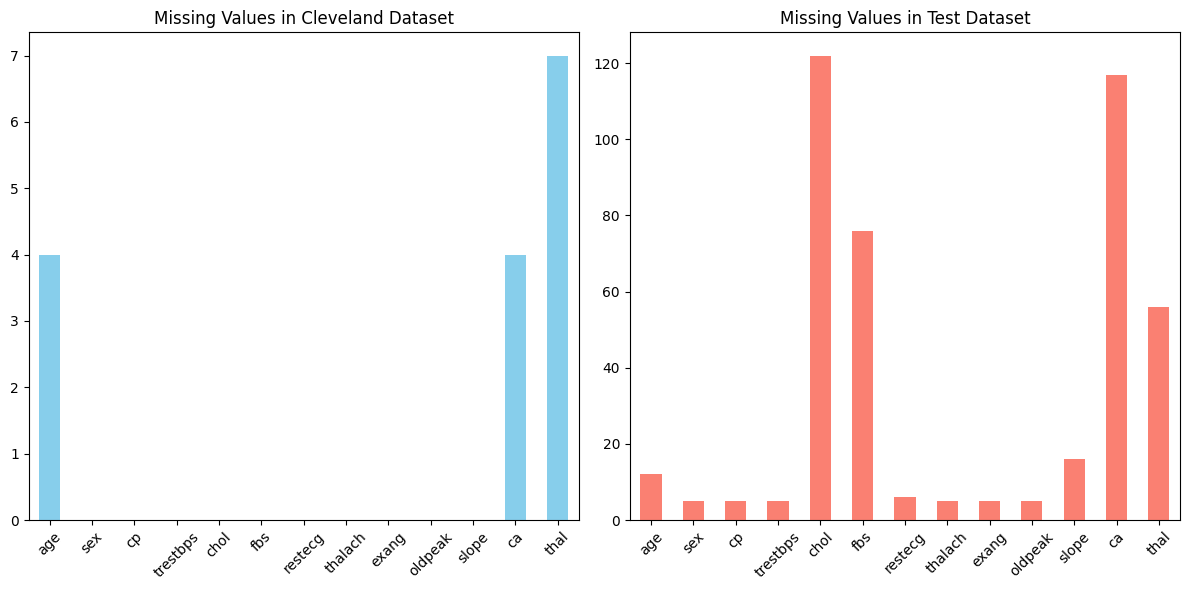

In [68]:
# Create 1 figure with a set of 2 subplots. Each axes should contain a figure as described below: 
# subplot 1: A barplot with the missing valies for each attribute in the dataset 'cleveland'
# subplot 2: A barplot with the missing valies for each attribute in the dataset 'test'

# Write your code here
# make a copy
cleveland_copy = cleveland.copy()
test_copy = test.copy()
# check by type
categorical_columns = ['sex','cp','fbs','restecg','exang','slope','ca','thal']        # change this
numerical_columns_int = ['age','trestbps','chol','thalach']      # change this
numerical_columns_float = ['oldpeak']    # change this
# cleveland 
# categorical
for column in categorical_columns:
    print(f"Unique values for {column}:")
    print(cleveland_copy[column].unique())
    print("\n")
    
cleveland_copy[categorical_columns] = cleveland_copy[categorical_columns].replace({'?': np.nan, '!': np.nan}) # convert to na

# numerical
cleveland_copy.loc[(cleveland_copy['age'] <= 0) | (cleveland_copy['age'] > 120), 'age'] = np.nan # convert to na

missing_values_1 = cleveland_copy.isnull().sum()
missing_values_1 = missing_values_1.drop('num')
print(missing_values_1)



# test

# categorical
for column in categorical_columns:
    print(f"Unique values for {column}:")
    print(test_copy[column].unique())
    print("\n")
    
test_copy[categorical_columns] = test_copy[categorical_columns].replace('?', np.nan)

# numerical
test_copy.loc[(test_copy['age'] <= 0) | (test_copy['age'] > 120), 'age'] = np.nan # convert to na
test_copy['chol'] = test_copy['chol'].replace(0, np.nan)

# missing values
missing_values_2 = test_copy.isnull().sum()
missing_values_2 = missing_values_2.drop('num')
print(missing_values_2)

# Create a figure with 2 subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# Subplot 1: Missing values for cleveland dataset
missing_values_1.plot(kind='bar', ax=axs[0], color='skyblue')
axs[0].set_title('Missing Values in Cleveland Dataset')
axs[0].set_xticklabels(missing_values_1.index, rotation=45)
# Subplot 2: Missing values for test dataset
missing_values_2.plot(kind='bar', ax=axs[1], color='salmon')
axs[1].set_title('Missing Values in Test Dataset')
axs[1].set_xticklabels(missing_values_2.index, rotation=45)
# Adjust layout
plt.tight_layout()
plt.show()

test_copy = test_copy.iloc[:-5] # drop the unnecessary last 5 rows for future imputation

## *3.* Imputing categorical variables

In the file 'data/heart-disease.names' you can find, together with the names of the columns, a description of their contents.

Determine which columns are categorical, and set their type to object.

Determine which columns are numerical, and set their type accordingly.

In [69]:
categorical_columns = ['sex','cp','fbs','restecg','exang','slope','ca','thal']        # change this
numerical_columns_int = ['age','trestbps','chol','thalach']      # change this
numerical_columns_float = ['oldpeak']    # change this

### ` Task: Split the cleveland dataframe in a train and a validation set. `

The train set must be called train, the the validation set must be called val. The size of the validation set must be 30% of the total size of the cleveland dataframe. Use shuffle=True and stratify=True. Make sure that both train and val are dataframes, and that the columns have the correct names. Reset the indexes of all four the dataframes, using drop=True.

In [70]:
# Split the data into X and y, where X contains the features and y contains the target variable.
X_cleveland = cleveland_copy.drop('num', axis=1)  # change this
y_cleveland = cleveland_copy['num']   # change this

X_test = test_copy.drop('num', axis=1)      # change this
y_test = test_copy['num']       # change this

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_cleveland, 
    y_cleveland, 
    test_size=0.3, 
    shuffle=True, 
    stratify=y_cleveland, 
    random_state=8
)

In [72]:
# DO NOT DELETE/CHANGE THIS CELL
X_train.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
231,55.0,0.0,4.0,180.0,327.0,0.0,1.0,117.0,1.0,3.4,2.0,0.0,3.0
222,39.0,0.0,3.0,94.0,199.0,0.0,0.0,179.0,0.0,0.0,1.0,0.0,3.0
114,62.0,0.0,3.0,130.0,263.0,0.0,0.0,97.0,0.0,1.2,2.0,1.0,7.0
276,66.0,0.0,3.0,146.0,278.0,0.0,2.0,152.0,0.0,0.0,2.0,1.0,3.0
265,42.0,1.0,4.0,136.0,315.0,0.0,0.0,125.0,1.0,1.8,2.0,0.0,6.0


In [73]:
# DO NOT DELETE/CHANGE THIS CELL
X_val.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
158,NaN,1.0,4.0,140.0,293.0,0.0,2.0,170.0,0.0,1.2,2.0,2.0,7.0
15,57.0,1.0,3.0,150.0,168.0,0.0,0.0,174.0,0.0,1.6,1.0,0.0,3.0
244,60.0,0.0,3.0,120.0,178.0,1.0,0.0,96.0,0.0,0.0,1.0,0.0,3.0
194,68.0,0.0,3.0,120.0,211.0,0.0,2.0,115.0,0.0,1.5,2.0,0.0,3.0
32,64.0,1.0,3.0,140.0,335.0,0.0,0.0,158.0,0.0,0.0,1.0,0.0,3.0


In [74]:
# To make the classification task easier, transform the target variable into a binary variable.
# If the target variable is 0, it should remain 0. If the target variable is different from 0, it should be transformed into 1.
y_train = pd.DataFrame((y_train != 0).astype(int))  # change this
y_val = pd.DataFrame((y_val != 0).astype(int))    # change this
y_test = pd.DataFrame((y_test != 0).astype(int))   # change this

In [75]:
# DO NOT DELETE/CHANGE THIS CELL

'''
train_set_from_franco = pd.read_csv('../../../testing_data/train.csv')
val_set_from_franco = pd.read_csv('../../../testing_data/val.csv')

assert train.equals(train_set_from_franco), 'train set is not correct'
assert val.equals(val_set_from_franco), 'validation set is not correct'
'''


"\ntrain_set_from_franco = pd.read_csv('../../../testing_data/train.csv')\nval_set_from_franco = pd.read_csv('../../../testing_data/val.csv')\n\nassert train.equals(train_set_from_franco), 'train set is not correct'\nassert val.equals(val_set_from_franco), 'validation set is not correct'\n"

### ` Task: impute the missing values in the categorical columns. Use a KNNImputer from sklearn for the imputation process. `

In [76]:
# 1. Create a subset of the train dataset with only the categorical columns. Call this subset train_cat.
# 2. Create a subset of the val dataset with only the categorical columns. Call this subset val_cat.
# 3. Create a subset of the test dataset with only the categorical columns. Call this subset test_cat
# 4. Impute the three datasets using a KNN imputer with k=5 and weights set to distance
# 5. Save the results in train_imputed_knn, val_imputed_knn, and test_imputed_knn.
# 6. Make sure to add the column names to the resulting dataframes. DO NOT SKIP THIS STEP.
# The new values might have new values that are not in the original dataset.
# Approximate them to the nearest value in the original dataset, for each column.
# To do so, you can store the original values of each column in a dictionary or a list.
# if a new value is equidistant from two original values, choose the largest one.
# (Example: if the original values are [1, 3] and the new value is 2, it will become 3)

from sklearn.impute import KNNImputer

# Write your code here

# 1. Create a subset of the train dataset with only the categorical columns.
train_cat = X_train[categorical_columns]

# 2. Create a subset of the val dataset with only the categorical columns.
val_cat = X_val[categorical_columns]

# 3. Create a subset of the test dataset with only the categorical columns.
test_cat = X_test[categorical_columns]

# 4. Impute the three datasets using a KNN imputer with k=5 and weights set to distance
imputer = KNNImputer(n_neighbors=5, weights='distance')

# Impute the train, val, and test datasets
train_imputed_knn = imputer.fit_transform(train_cat)
val_imputed_knn = imputer.transform(val_cat)
test_imputed_knn = imputer.transform(test_cat)

categories = {
    'sex': [0, 1],
    'cp': [0, 1, 2, 3, 4],
    'fbs': [0, 1],
    'restecg': [0, 1, 2],
    'exang': [0, 1],
    'slope': [1, 2, 3],
    'ca': [0, 1, 2, 3],
    'thal': [3, 6, 7]
}

def find_nearest_category(value, categories):
    if value in categories:
        return value
    # If the distances to both endpoints are equal, choose the larger one
    if value < min(categories):
        return min(categories)
    if value > max(categories):
        return max(categories)
    nearest = min(categories, key=lambda x: (abs(x - value), -x if x == 0 else x))
    return nearest

for i, col in enumerate(categorical_columns):
    train_imputed_knn[:, i] = [find_nearest_category(val, categories[col]) for val in train_imputed_knn[:, i]]
    val_imputed_knn[:, i] = [find_nearest_category(val, categories[col]) for val in val_imputed_knn[:, i]]
    test_imputed_knn[:, i] = [find_nearest_category(val, categories[col]) for val in test_imputed_knn[:, i]]
    
# 5. Convert the imputed results back to DataFrames and add column names
train_imputed_knn = pd.DataFrame(train_imputed_knn, columns=train_cat.columns)
val_imputed_knn = pd.DataFrame(val_imputed_knn, columns=val_cat.columns)
test_imputed_knn = pd.DataFrame(test_imputed_knn, columns=test_cat.columns)


In [77]:
# DO NOT DELETE/CHANGE THIS CELL
'''
train_imp_knn_franco = pd.read_csv('../../../testing_data/train_imp_knn.csv')
val_imp_knn_franco = pd.read_csv('../../../testing_data/val_imp_knn.csv')
test_imp_knn_franco = pd.read_csv('../../../testing_data/test_imp_knn.csv')

assert train_imputed_knn.equals(train_imp_knn_franco), 'train imputed knn is not correct'
assert val_imputed_knn.equals(val_imp_knn_franco), 'val imputed knn is not correct'
assert test_imputed_knn.equals(test_imp_knn_franco), 'test imputed knn is not correct'
'''

"\ntrain_imp_knn_franco = pd.read_csv('../../../testing_data/train_imp_knn.csv')\nval_imp_knn_franco = pd.read_csv('../../../testing_data/val_imp_knn.csv')\ntest_imp_knn_franco = pd.read_csv('../../../testing_data/test_imp_knn.csv')\n\nassert train_imputed_knn.equals(train_imp_knn_franco), 'train imputed knn is not correct'\nassert val_imputed_knn.equals(val_imp_knn_franco), 'val imputed knn is not correct'\nassert test_imputed_knn.equals(test_imp_knn_franco), 'test imputed knn is not correct'\n"

## *4.* Imputing numerical variables

### ` Task: impute the missing values in the numerical columns. Use a Lasso Regression from sklearn for the imputation process. `
If more than one column contains missing values, proceed in increasing order: the lowest number of missing values first, then the second lowest, then the third ...

Exclude the columns with missing values when fitting your regressor: only train on columns without missing values. After a column has been imputed, it can be used to fit the regressor in the next step.

In [78]:
# 1. Create a subset of the train dataset with only the numerical columns. Call this subset train_num.
# 2. Create a subset of the val dataset with only the numerical columns. Call this subset val_num.
# 3. Create a subset of the test dataset with only the numerical columns. Call this subset test_num.
# 4a. Create a subset of train_num containing the rows with missing values. Call this subset train_num_missing.
# 4b. Create a subset of train_num containing the rows without missing values. Call this subset train_num_not_missing.
# 5a. Create a subset of val_num containing the rows with missing values. Call this subset val_num_missing.
# 5b. Create a subset of val_num containing the rows without missing values. Call this subset val_num_not_missing.
# 6a. Create a subset of test_num containing the rows with missing values. Call this subset test_num_missing.
# 6b. Create a subset of test_num containing the rows without missing values. Call this subset test_num_not_missing.
# 7. Using a Lasso regression, impute the missing values in train_num_missing, val_num_missing, and test_num_missing.
# On what should the Lasso regression be trained?
# 8. Repeat steps 1-7 until all the missing values are imputed.
# 9. Save the results in train_num_imputed_lasso, val_num_imputed_lasso, and test_num_imputed_lasso.
# 10. Concatenate the imputed subsets with the subsets that did not contain missing values.
# 11. Save the resulting datasets in train_imputed_lasso, val_imputed_lasso, and test_imputed_lasso.
# IMPORTANT: The order of the rows should be the same as in the original datasets.

from sklearn.linear_model import Lasso

# Write your code here
train_num = X_train[numerical_columns_int + numerical_columns_float]
val_num = X_val[numerical_columns_int + numerical_columns_float]
test_num = X_test[numerical_columns_int + numerical_columns_float]  
test_num_part = X_test[['age','trestbps','thalach','oldpeak']]

def get_missing_and_not_missing(data):
    missing = data[data.isnull().any(axis=1)]
    not_missing = data[data.notnull().all(axis=1)]
    return missing, not_missing

# 4-6: Get missing and not missing subsets
train_num_missing, train_num_not_missing = get_missing_and_not_missing(train_num)
val_num_missing, val_num_not_missing = get_missing_and_not_missing(val_num)
test_num_missing, test_num_not_missing = get_missing_and_not_missing(test_num_part)


# Separate features and target
X_train_1 = train_num_not_missing.drop(columns=['age'])
y_train_1 = train_num_not_missing['age']
# Train the Lasso regression model
lasso = Lasso(alpha=0.1)  
lasso.fit(X_train_1, y_train_1)
# Predict missing values
predicted_age_1 = lasso.predict(train_num_missing.drop(columns=['age']))
# Impute missing values
train_num_missing.loc[train_num_missing['age'].isnull(), 'age'] = predicted_age_1
train_num_imputed_lasso = train_num_missing



# Separate features and target
X_train_2 = val_num_not_missing.drop(columns=['age'])
y_train_2 = val_num_not_missing['age']

# Train the Lasso regression model
lasso = Lasso(alpha=0.1)  
lasso.fit(X_train_2, y_train_2)

# Predict missing values
predicted_age_2 = lasso.predict(val_num_missing.drop(columns=['age']))

# Impute missing values
val_num_missing.loc[val_num_missing['age'].isnull(), 'age'] = predicted_age_2
val_num_imputed_lasso = val_num_missing




# Separate features and target
X_train_3 = test_num_not_missing.drop(columns=['age'])
y_train_3 = test_num_not_missing['age']

# Train the Lasso regression model
lasso = Lasso(alpha=0.1)  
lasso.fit(X_train_3, y_train_3)

# Predict missing values
predicted_age_3 = lasso.predict(test_num_missing.drop(columns=['age']))  

# Impute missing values
test_num_missing.loc[test_num_missing['age'].isnull(), 'age'] = predicted_age_3
test_num_imputed_lasso = test_num_missing

# 10. Concatenate the imputed subsets with the non-missing subsets
train_imputed_lasso = pd.concat([train_num_imputed_lasso, train_num_not_missing]).sort_index()
val_imputed_lasso = pd.concat([val_num_imputed_lasso, val_num_not_missing]).sort_index()
test_imputed_lasso = pd.concat([test_num_imputed_lasso, test_num_not_missing]).sort_index()





### train model for "chol" on train dataset
# Separate features and target
X_train_0 = train_num_not_missing.drop(columns=['chol'])
y_train_0 = train_num_not_missing['chol']
# Train the Lasso regression model
lasso = Lasso(alpha=0.1)  # Choose an appropriate alpha value
lasso.fit(X_train_0, y_train_0)

predicted_chol = lasso.predict(test_imputed_lasso)

test_imputed_lasso['chol'] = predicted_chol

### predict val "chol" value with train dataset model
# Separate features and target
X = val_imputed_lasso.drop(columns=['chol'])
y = val_imputed_lasso['chol']

# Predict missing values
predicted_chol_val = lasso.predict(X)

# evaluate 
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, predicted_chol_val)
r2 = r2_score(y, predicted_chol_val)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 3365.4659651553293
R² Score: 0.046206789743171384


In [79]:
# DO NOT DELETE/CHANGE THIS CELL
'''
train_imp_lasso_franco = pd.read_csv('../../../testing_data/train_imp_lasso.csv')
val_imp_lasso_franco = pd.read_csv('../../../testing_data/val_imp_lasso.csv')
test_imp_lasso_franco = pd.read_csv('../../../testing_data/test_imp_lasso.csv')

assert train_imputed_lasso.equals(train_imp_lasso_franco), 'train imputed lasso is not correct'
assert val_imputed_lasso.equals(val_imp_lasso_franco), 'val imputed lasso is not correct'
assert test_imputed_lasso.equals(test_imp_lasso_franco), 'test imputed lasso is not correct'
'''

"\ntrain_imp_lasso_franco = pd.read_csv('../../../testing_data/train_imp_lasso.csv')\nval_imp_lasso_franco = pd.read_csv('../../../testing_data/val_imp_lasso.csv')\ntest_imp_lasso_franco = pd.read_csv('../../../testing_data/test_imp_lasso.csv')\n\nassert train_imputed_lasso.equals(train_imp_lasso_franco), 'train imputed lasso is not correct'\nassert val_imputed_lasso.equals(val_imp_lasso_franco), 'val imputed lasso is not correct'\nassert test_imputed_lasso.equals(test_imp_lasso_franco), 'test imputed lasso is not correct'\n"

## *5.* Classification with Decision Tree, using a single split 

In [80]:
# Merge the train_imputed_knn and train_imputed_lasso datasets. Call the resulting dataset X_train_imputed.
# Merge the val_imputed_knn and val_imputed_lasso datasets. Call the resulting dataset X_val_imputed.
# Merge the test_imputed_knn and test_imputed_lasso datasets. Call the resulting dataset X_test_imputed.

# Write your code here

X_train_imputed = pd.concat([train_imputed_knn.reset_index(drop=True), train_imputed_lasso.reset_index(drop=True)], axis=1)  
X_val_imputed = pd.concat([val_imputed_knn.reset_index(drop=True), val_imputed_lasso.reset_index(drop=True)], axis=1)        
X_test_imputed = pd.concat([test_imputed_knn.reset_index(drop=True), test_imputed_lasso.reset_index(drop=True)], axis=1)    

### ` Task: Train a set of Decision Trees, using different hyperparameters. Use the best performing Decision Tree to predict the class for the test set. `

In [81]:
# 1. Create a dictionary to contain the hyperparameters. The dictionary should contain the following:
# - criterion: 'gini' and 'entropy'
# - max_depth: 3, 5, and 7
# - min_samples_split: 2, 5, and 10
# 2. Create a dictionary called performance to store the hyperparameter combinations and the corresponding performance of the model.
# 3. Create a ParameterGrid object with the hyperparameters from the dictionary.
# 4. Create a for loop to iterate over the combinations of hyperparameters.
# 5. In each iteration
# - Create a DecisionTreeClassifier with the hyperparameters for that iteration.
# - Fit the model.
# - Predict the target variable for the validation set.
# - Calculate the F1 score of the model.
# - Add the hyperparameters and the F1 score to the performance dictionary.

from sklearn.model_selection import ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import time

hyperparameters = {'criterion': ['gini', 'entropy'],
                   'max_depth': [3, 5, 7],
                   'min_samples_split': [2, 5, 10]
} 
# add missing steps here
# Step 2: Create a dictionary called performance to store the hyperparameter combinations and the corresponding performance of the model
performance = {}

# Step 3: Create a ParameterGrid object with the hyperparameters from the dictionary
param_grid = ParameterGrid(hyperparameters)

start = time.time() # DO NOT CHANGE/DELETE THIS LINE

for params in param_grid: # change this
    # - Create a DecisionTreeClassifier with the hyperparameters for that iteration
    clf = DecisionTreeClassifier(**params)
    
    # - Fit the model
    clf.fit(X_train, y_train)
    
    # - Predict the target variable for the validation set
    y_pred = clf.predict(X_val)
    
    # - Calculate the F1 score of the model
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    # - Add the hyperparameters and the F1 score to the performance dictionary
    performance[tuple(params.items())] = f1

end = time.time() # DO NOT CHANGE/DELETE THIS LINE

print('Time elapsed to run the hyperparameter tuning with a single split: ', end - start) # DO NOT CHANGE/DELETE THIS LINE

Time elapsed to run the hyperparameter tuning with a single split:  0.08024239540100098


In [82]:
# select the best performing hyperparameters
best_hyperparameters = max(performance, key=performance.get) # change this
best_hyperparameters = dict(best_hyperparameters)
best_hyperparameters

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

In [83]:
# Concatenate the train and validation datasets. Call the resulting datasets X and y.
X = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_val)], ignore_index=True)
y = pd.concat([pd.DataFrame(y_train), pd.DataFrame(y_val)], ignore_index=True)

# Create a DecisionTreeClassifier with the best hyperparameters.
# Fit the model on the X and y datasets.

# Write your code here
best_clf = DecisionTreeClassifier(**best_hyperparameters)
best_clf.fit(X, y)
# Predict the target variable for the test dataset.

# Write your code here
y_test_pred = best_clf.predict(X_test)

# Calculate the F1 score of the model on the test dataset. Call the variable f1_test_single_split.

# Write your code here
f1_test_single_split = f1_score(y_test, y_test_pred, average='weighted') # change this


In [84]:
f1_test_single_split # DO NOT DELETE/CHANGE THIS LINE

np.float64(0.5223117623117624)

## *6.* Classification with Decision Tree using Cross Validation

### ` Task: Train a cross-validation object, then train a decision tree using cross-validation and different hyperparameters. Use the best performing Decision Tree to predict the class for the test set. `

In [85]:
# 1. Use the same hyperparameters from the previous task.
# 2. Create a StratifiedKFold object with 5 splits, use shuffle=True.
# 3. Create a dictionary called performance_CV to store the hyperparameter combinations and the corresponding performance of the model.
# 3. Create a ParameterGrid object with the usual hyperparameters.
# 4. Create a for loop to iterate over the folds of the StratifiedKFold.
# 5. For each fold, create a for loop to iterate over the combinations of hyperparameters.
# 6. In each iteration
# - Create a DecisionTreeClassifier with the hyperparameters for that iteration.
# - Fit the model.
# - Predict the target variable for the validation fold.
# - Calculate the F1 score of the model.
# - Add the hyperparameters and the F1 score to the performance dictionary. Each hyperparameter combination may have multiple F1 scores.

from sklearn.model_selection import StratifiedKFold


# DO NOT FORGET TO DELETE THE PREVIOUS LINES. They are only to make the empty assignment run without errors,
# but they will destroy the data you need.

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)

# add missing steps here
performance_CV = {}

# Create a ParameterGrid object
param_grid = ParameterGrid(hyperparameters)

start_CV = time.time() # DO NOT CHANGE/DELETE THIS LINE

for i, (train_index, val_index) in enumerate(CV.split(X, y)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    for params in param_grid:
        # Create a DecisionTreeClassifier with the hyperparameters for that iteration
        model = DecisionTreeClassifier(**params)
        
        # Fit the model
        model.fit(X_train, y_train.values.ravel())
        
        # Predict the target variable for the validation fold
        y_pred = model.predict(X_val)
        
        # Calculate the F1 score of the model
        f1 = f1_score(y_val, y_pred)
        
        # Add the hyperparameters and the F1 score to the performance dictionary
        # If the hyperparameters combination is not yet in the dictionary, initialize it
        param_tuple = tuple(params.items())  # Convert params to a tuple for use as a dictionary key
        if param_tuple not in performance_CV:
            performance_CV[param_tuple] = []
        performance_CV[param_tuple].append(f1)
        
end_CV = time.time() # DO NOT CHANGE/DELETE THIS LINE

print('Time elapsed to run the hyperparameter tuning with Cross Validation: ', end_CV - start_CV) # DO NOT CHANGE/DELETE THIS LINE


Time elapsed to run the hyperparameter tuning with Cross Validation:  0.3321959972381592


In [86]:
# select the best performing hyperparameters, which are the ones with the highest average F1 score
average_f1_scores = {params: np.mean(scores) for params, scores in performance_CV.items()}
best_hyperparameters_CV = max(average_f1_scores, key=average_f1_scores.get)
best_hyperparameters_CV # DO NOT DELETE/CHANGE THIS LINE


(('criterion', 'entropy'), ('max_depth', 3), ('min_samples_split', 5))

In [87]:
# Create a DecisionTreeClassifier with the best hyperparameters.
# Fit the model on the X and y datasets.
# Call the fitted model final_tree.

# Write your code here
final_tree = DecisionTreeClassifier(**dict(best_hyperparameters_CV))
# Predict the target variable for the test dataset.

# Write your code here
final_tree.fit(X, y.values.ravel())
y_pred_test = final_tree.predict(X_test)
# Calculate the F1 score of the model on the test dataset. Call the variable f1_test_CV.

# Write your code here
f1_test_CV = f1_score(y_test, y_pred_test)

In [88]:
f1_test_CV # DO NOT DELETE/CHANGE THIS LINE

np.float64(0.4755244755244755)

## *7.* Interpretation of the results 

### ` Task: Look at the times elapsed to train the Decision Tree using the single split and the CV strategies. Is there a difference? Explain the difference or the lack of difference in 50 words or less. `

The single split method is faster (0.074s) because it evaluates the model on one training/test split, while Cross Validation (0.318s) assesses performance across multiple splits, which involves more computations and increases training time. This trade-off enhances model reliability at the cost of increased time.

### ` Task: Plot final_tree, and explain which feature or combination of features is the most relevant for that model, in 50 words or less. `

You can find instructions on how to plot a decision tree at [this link](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py).

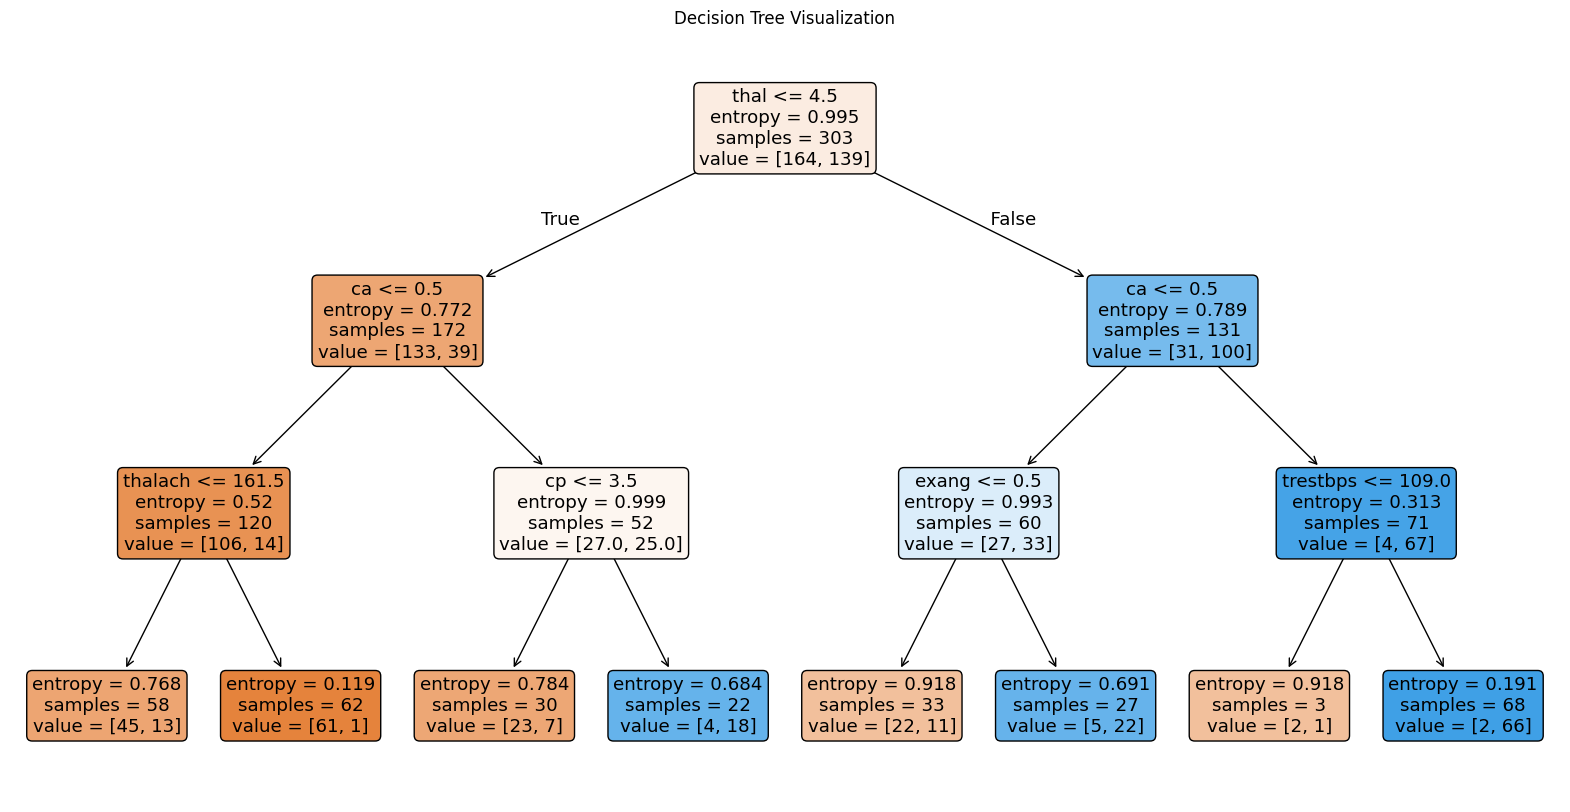

In [89]:
# plot your tree here.
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(final_tree, filled=True, feature_names=X.columns, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

The most relevant feature is "thal", which appears in the first split of the tree, indicating it has the highest information gain. This feature significantly influences the model's decisions and predictions.